In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("DataSets/olist_customers_dataset.csv")
orders = pd.read_csv("DataSets/olist_orders_dataset.csv")
order_items = pd.read_csv("DataSets/olist_order_items_dataset.csv")
products = pd.read_csv("DataSets/olist_products_dataset.csv")
payments = pd.read_csv("DataSets/olist_order_payments_dataset.csv")
reviews = pd.read_csv("DataSets/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("DataSets/olist_sellers_dataset.csv")
geolocation = pd.read_csv("DataSets/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("DataSets/product_category_name_translation.csv")

#### 12. How reliable is the merge across multiple source files? 
Output: row-count checks, merge-validation notes, unmatched-record summary, 
and a final integrity check. This is an excellent real-world task because the dataset 
is explicitly multi-file.

In [3]:
geolocation = geolocation.drop_duplicates(
    subset=["geolocation_zip_code_prefix"]
)

In [19]:
merged_df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
    .merge(
        geolocation,
        left_on="customer_zip_code_prefix",
        right_on="geolocation_zip_code_prefix",
        how="left"
    )
)

merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,9350.0,maua,SP,housewares,3149.0,-23.574809,-46.587471,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,31570.0,belo horizonte,SP,perfumery,47813.0,-12.169860,-44.988369,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,14840.0,guariba,SP,auto,75265.0,-16.746337,-48.514624,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,20.0,31842.0,belo horizonte,MG,pet_shop,59296.0,-5.767733,-35.275467,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,15.0,8752.0,mogi das cruzes,SP,stationery,9195.0,-23.675037,-46.524784,santo andre,SP


In [20]:
merged_df.shape

(113425, 35)

In [21]:
orders.shape

(99441, 8)

#### 11. What data quality issues appear in the merged dataset? 
Output: missing-value report, duplicate report, type-fix log, and a cleaned final file.

In [22]:
merged_df["customer_id"].isna().sum()


np.int64(0)

In [23]:
merged_df["product_id"].isna().sum()

np.int64(775)

In [24]:
merged_df["seller_id"].isna().sum()

np.int64(775)

In [28]:
  merged_df.duplicated().sum()

np.int64(0)

In [29]:
merged_df.isnull().sum()
    

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
seller_zip_c

In [31]:
# Type-Fix Log
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    merged_df[col] = pd.to_datetime(
        merged_df[col],
        errors="coerce"
    )

print(merged_df[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [33]:
# Revenue Column
merged_df["revenue"] = (
    merged_df["price"] +
    merged_df["freight_value"]
)

In [34]:
# Revenue by Category
revenue_by_category = (
    merged_df
    .groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_category.head(10)

,product_category_name_english,revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


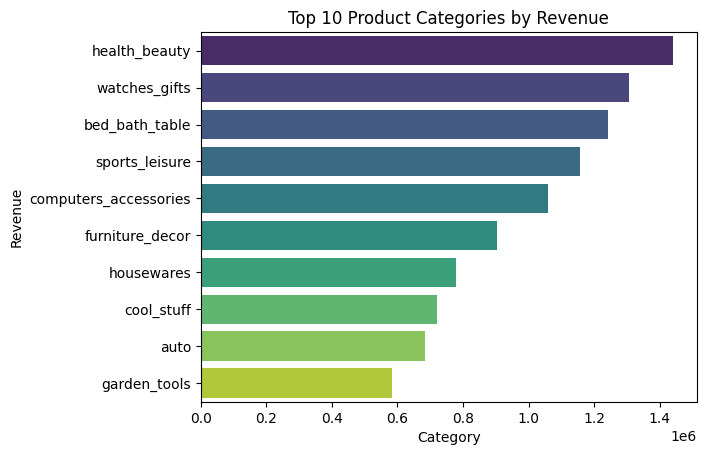

In [41]:
# Bar Chart
top10 = revenue_by_category.head(10)
sns.barplot(data=top10,x="revenue",y="product_category_name_english",  palette='viridis', hue='product_category_name_english', legend=False)
# top10.plot(
#     x="product_category_name_english",
#     y="revenue",
#     kind="bar",
#     figsize=(10,5)
# )

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

#### Insight:
The product categories with the highest revenue contribute the largest share of total sales and should be prioritized for inventory planning, marketing campaigns, and business growth strategies.

#### 2. Which cities or regions contribute the most sales? 
Output: a region-wise sales summary, a bar chart or map-style summary, and a 
conclusion on market concentration. This fits the geography part of the dataset and 
the “geographic performance” part of the EDA workflow.  

In [42]:
# Sales by City
city_sales = (
    merged_df
    .groupby("customer_city")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_sales.head(10)

,customer_city,price
0,sao paulo,1914924.54
1,rio de janeiro,992538.86
2,belo horizonte,355611.13
3,brasilia,301920.25
4,curitiba,211738.06
5,porto alegre,190562.08
6,campinas,187844.53
7,salvador,181104.42
8,guarulhos,144268.39
9,niteroi,117907.12


In [43]:
# Sales by State (Region)
state_sales = (
    merged_df
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_sales

,customer_state,price
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


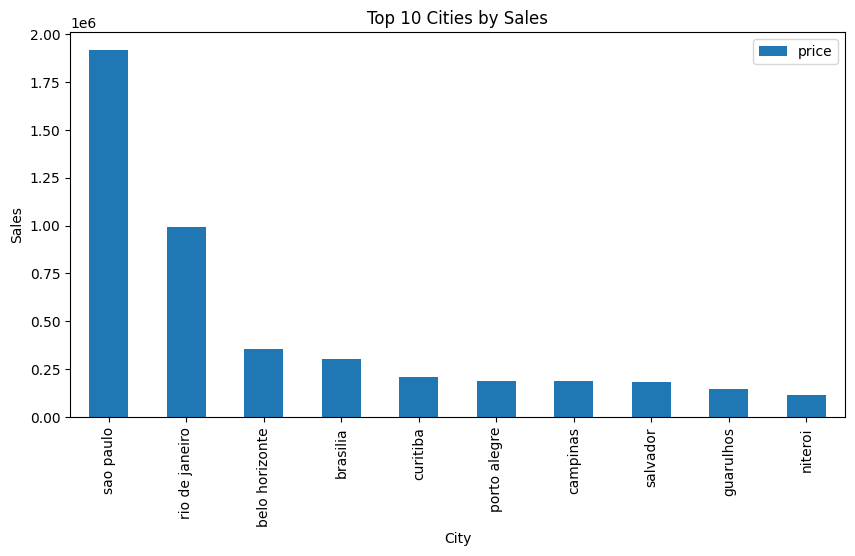

In [44]:
# Bar Chart - Top 10 Cities

top10_cities = city_sales.head(10)

top10_cities.plot(
    x="customer_city",
    y="price",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

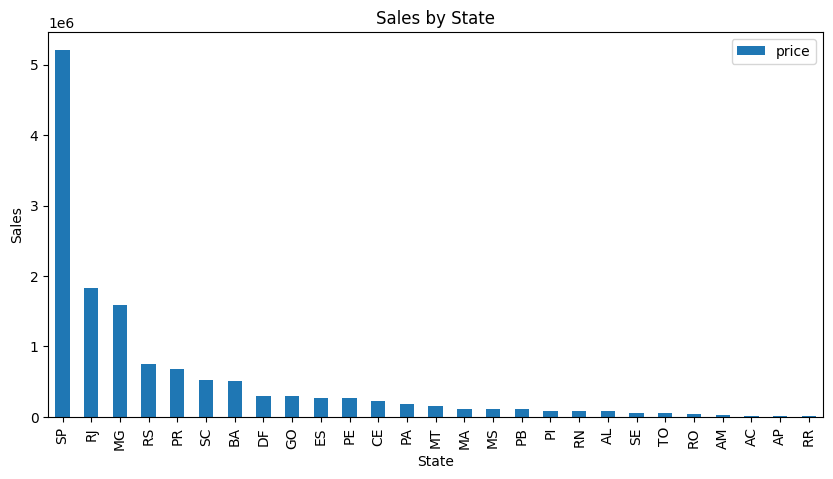

In [45]:
# Bar Chart - States

state_sales.plot(
    x="customer_state",
    y="price",
    kind="bar",
    figsize=(10,5)
)

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales")
plt.show()

#### Insight:
The cities and states with the highest sales contribute the largest share of revenue and represent the company's strongest markets.

#### 3. Which customer segments provide the highest business value? 
Output: a grouped customer analysis table, a chart comparing segments, and a 
written business interpretation. This trains students to move from raw rows to 
business grouping logic.  

In [48]:
# Customer Segments (Top States by Revenue)

customer_segments = (
    merged_df
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_segments.head(10)

,customer_state,price
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


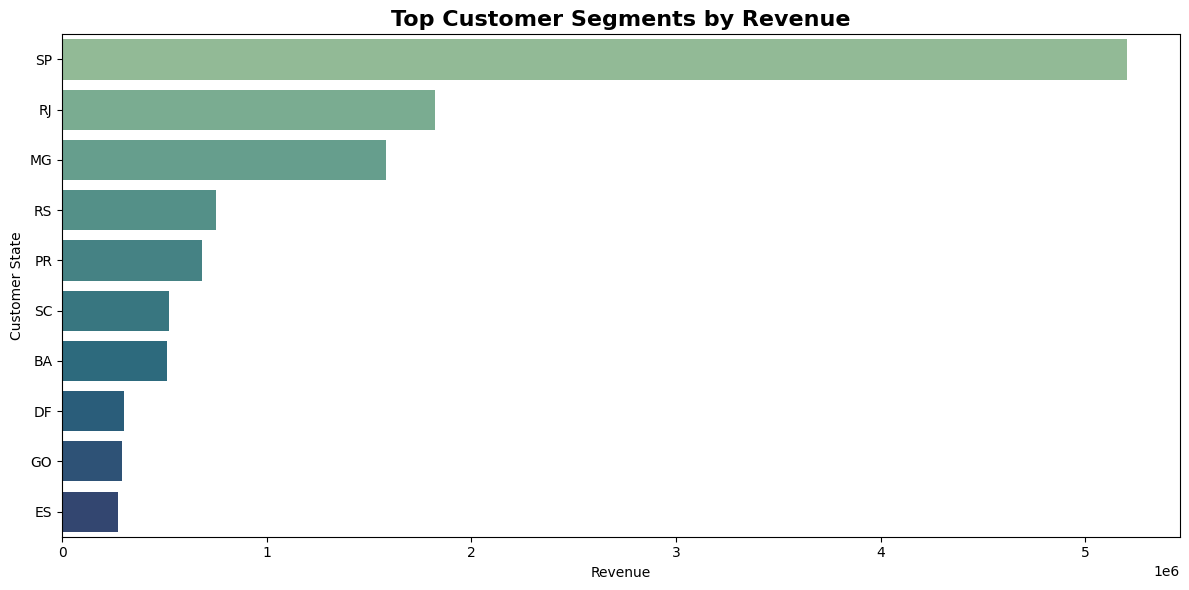

In [50]:
# Visualization

top10 = customer_segments.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="price",
    y="customer_state",
    hue="customer_state",
    palette="crest",
    legend=False
)

plt.title(
    "Top Customer Segments by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Customer State")



plt.tight_layout()
plt.show()

#### Insight:
Customer segments from these states generate the highest revenue and represent the most valuable customer groups for the business.

#### 4. What purchasing patterns can be observed in customer buying behavior? 
Output: frequency tables, trend plots, and a short behavioral summary. This is good 
for teaching EDA thinking rather than jumping into modeling too early. 

In [51]:
# Orders by Day of Week

merged_df["order_day"] = pd.to_datetime(
    merged_df["order_purchase_timestamp"]
).dt.day_name()

purchase_pattern = (
    merged_df
    .groupby("order_day")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

purchase_pattern

,order_day,total_orders
0,Friday,14122
1,Monday,16196
2,Saturday,10887
3,Sunday,11960
4,Thursday,14761
5,Tuesday,15963
6,Wednesday,15552


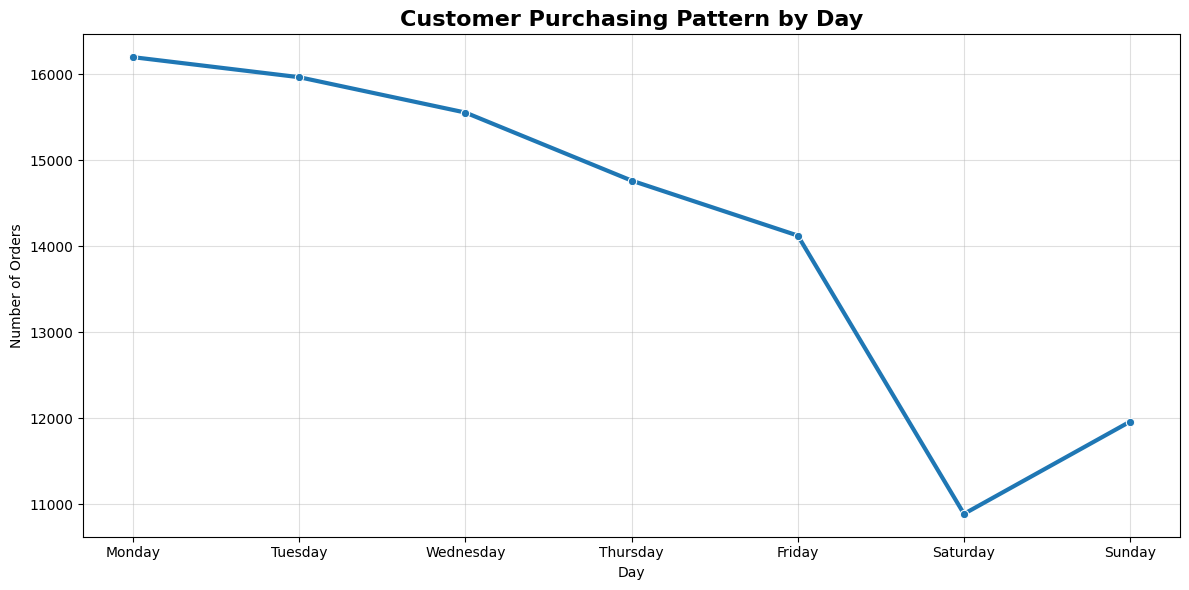

In [52]:
# Visualization

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

purchase_pattern["order_day"] = pd.Categorical(
    purchase_pattern["order_day"],
    categories=day_order,
    ordered=True
)

purchase_pattern = purchase_pattern.sort_values(
    "order_day"
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=purchase_pattern,
    x="order_day",
    y="total_orders",
    marker="o",
    linewidth=3
)

plt.title(
    "Customer Purchasing Pattern by Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

#### Insight:
The chart shows which days customers place the most orders, helping the business identify peak shopping periods and optimize marketing campaigns.

#### 5. Which products show the highest sales volume and revenue contribution? 
Output: product ranking table, top-10 visualization, and an insight note about top
performing products. This works well after students merge order-item and product 
data. 

In [53]:
# Top Products by Sales Volume

product_volume = (
    merged_df
    .groupby("product_id")["order_id"]
    .count()
    .reset_index(name="sales_volume")
    .sort_values(
        by="sales_volume",
        ascending=False
    )
)

product_volume.head(10)

,product_id,sales_volume
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,488
8613,422879e10f46682990de24d770e7f83d,484
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,388
10840,53759a2ecddad2bb87a079a1f1519f73,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,281
8051,3dd2a17168ec895c781a9191c1e95ad7,274


In [54]:
# Top Products by Revenue

merged_df["revenue"] = (
    merged_df["price"] +
    merged_df["freight_value"]
)

product_revenue = (
    merged_df
    .groupby("product_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="revenue",
        ascending=False
    )
)

product_revenue.head(10)

,product_id,revenue
24086,bb50f2e236e5eea0100680137654686c,67606.10
27039,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
14068,6cdd53843498f92890544667809f1595,59093.99
19742,99a4788cb24856965c36a24e339b6058,51071.60
27613,d6160fb7873f184099d9bc95e30376af,50326.18
8051,3dd2a17168ec895c781a9191c1e95ad7,48212.22
22112,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
12351,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
4996,25c38557cf793876c5abdd5931f922db,40311.95
10867,53b36df67ebb7c41585e8d54d6772e08,39957.93


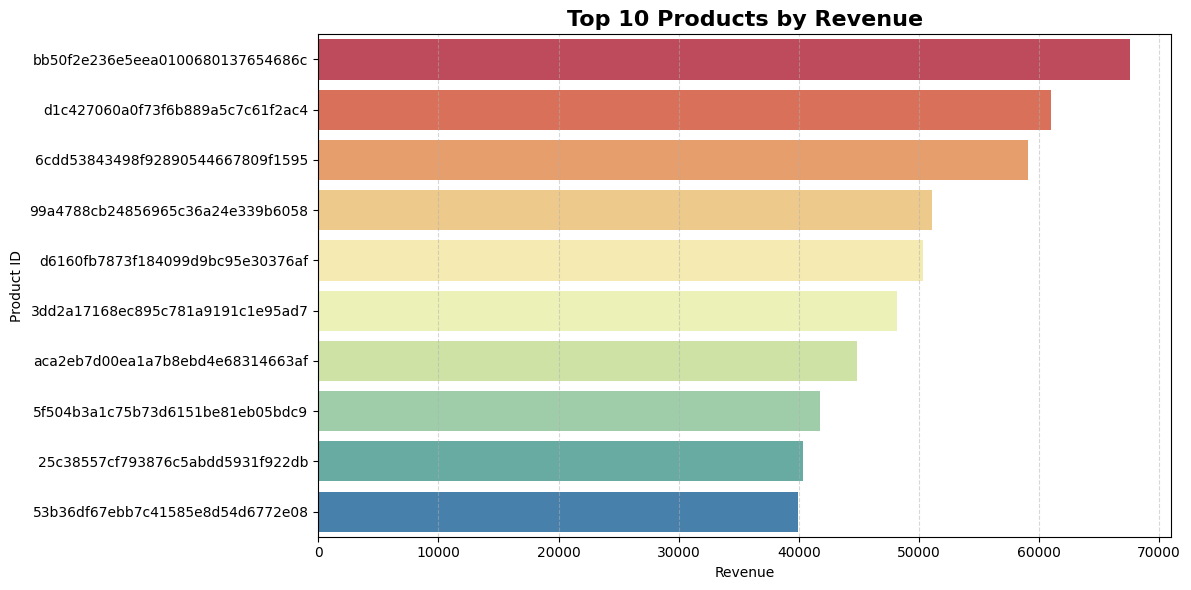

In [55]:
# Visualization

top10 = product_revenue.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="revenue",
    y="product_id",
    hue="product_id",
    palette="Spectral",
    legend=False
)

plt.title(
    "Top 10 Products by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Product ID")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
The highest-performing products generate a significant share of total revenue and sales volume, making them key products for inventory planning and promotional campaigns.

#### 6. How do payment methods influence purchasing trends? 
Output: payment-method summary, transaction counts, and a comparison chart 
with interpretation. This is a strong business question because the dataset explicitly 
includes payments.  

In [56]:
# Merge Payments

payment_df = merged_df.merge(
    payments,
    on="order_id",
    how="left"
)

In [57]:
# Payment Method Summary

payment_summary = (
    payment_df
    .groupby("payment_type")
    .agg(
        transaction_count=("order_id", "count"),
        total_revenue=("payment_value", "sum")
    )
    .reset_index()
    .sort_values(
        by="total_revenue",
        ascending=False
    )
)

payment_summary

,payment_type,transaction_count,total_revenue
1,credit_card,87286,15694885.84
0,boleto,23037,4086820.71
4,voucher,6407,432602.19
2,debit_card,1698,256417.92
3,not_defined,3,0.00


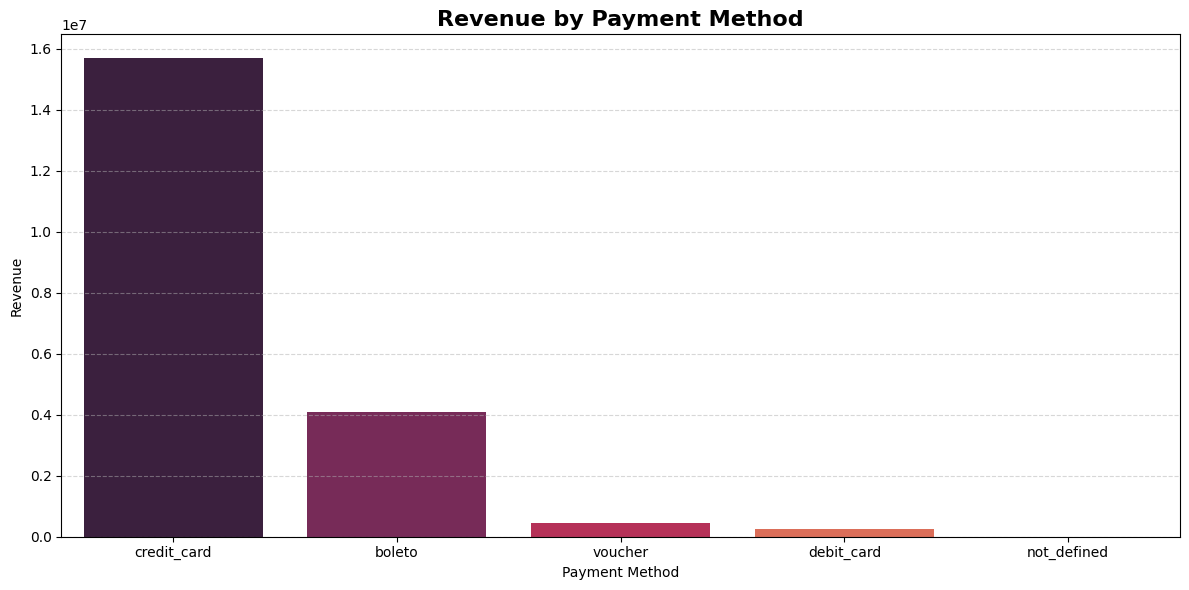

In [58]:
# Visualization

plt.figure(figsize=(12,6))

sns.barplot(
    data=payment_summary,
    x="payment_type",
    y="total_revenue",
    hue="payment_type",
    palette="rocket",
    legend=False
)

plt.title(
    "Revenue by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
The most frequently used payment methods contribute the highest revenue and indicate customer payment preferences.

#### 7. Which sellers contribute the most value? 
Output: seller ranking, top-seller chart, and a brief recommendation. This helps 
students practice grouping and ranking across a joined dataset. 

In [59]:
# Seller Ranking by Revenue

merged_df["revenue"] = (
    merged_df["price"] +
    merged_df["freight_value"]
)

seller_ranking = (
    merged_df
    .groupby("seller_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="revenue",
        ascending=False
    )
)

seller_ranking.head(10)

,seller_id,revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44
1013,53243585a1d6dc2643021fd1853d8905,235856.68
881,4a3ca9315b744ce9f8e9374361493884,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38
1824,955fee9216a65b617aa5c0531780ce60,160602.68


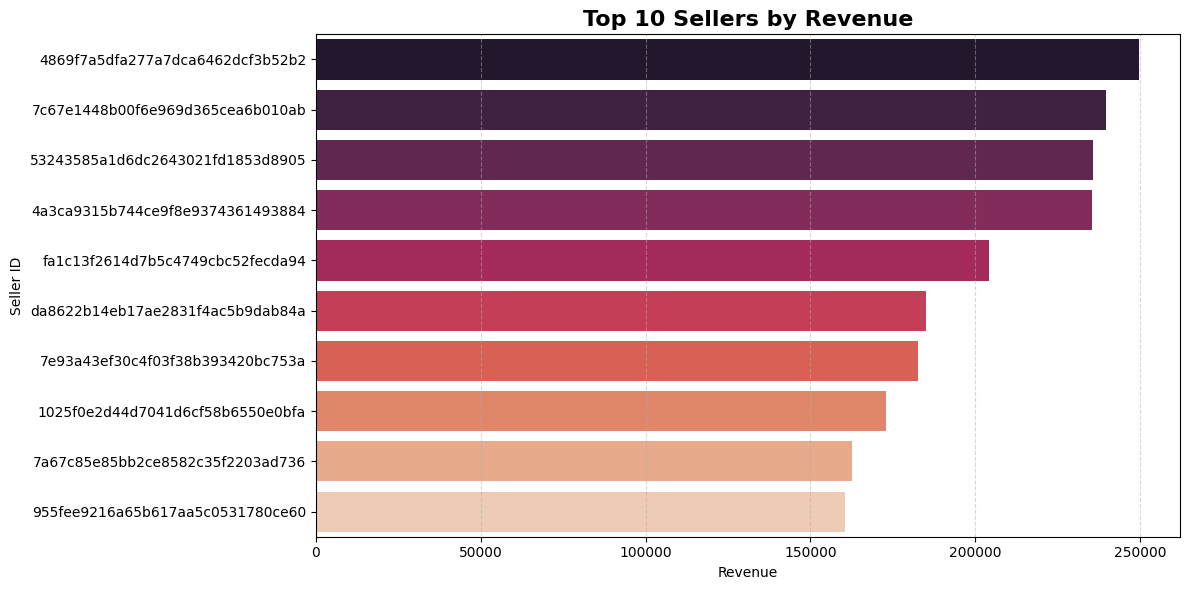

In [60]:
# Visualization

top10 = seller_ranking.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="revenue",
    y="seller_id",
    hue="seller_id",
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 Sellers by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
The top sellers generate the highest revenue and contribute significantly to overall business performance.

#### 8. How do review scores vary across categories or regions? 
Output: grouped review summary, box plot or bar chart, and a quality-focused 
conclusion. This is useful for connecting customer feedback to business 
performance.  

In [61]:
# Merge Reviews

review_df = merged_df.merge(
    reviews,
    on="order_id",
    how="left"
)

In [62]:
# Average Review Score by Category

category_reviews = (
    review_df
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .reset_index()
    .sort_values(
        by="review_score",
        ascending=False
    )
)

category_reviews.head(10)

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355
9,books_imported,4.400000
10,books_technical,4.368421
37,food_drink,4.315412
53,luggage_accessories,4.315257
64,small_appliances_home_oven_and_coffee,4.302632


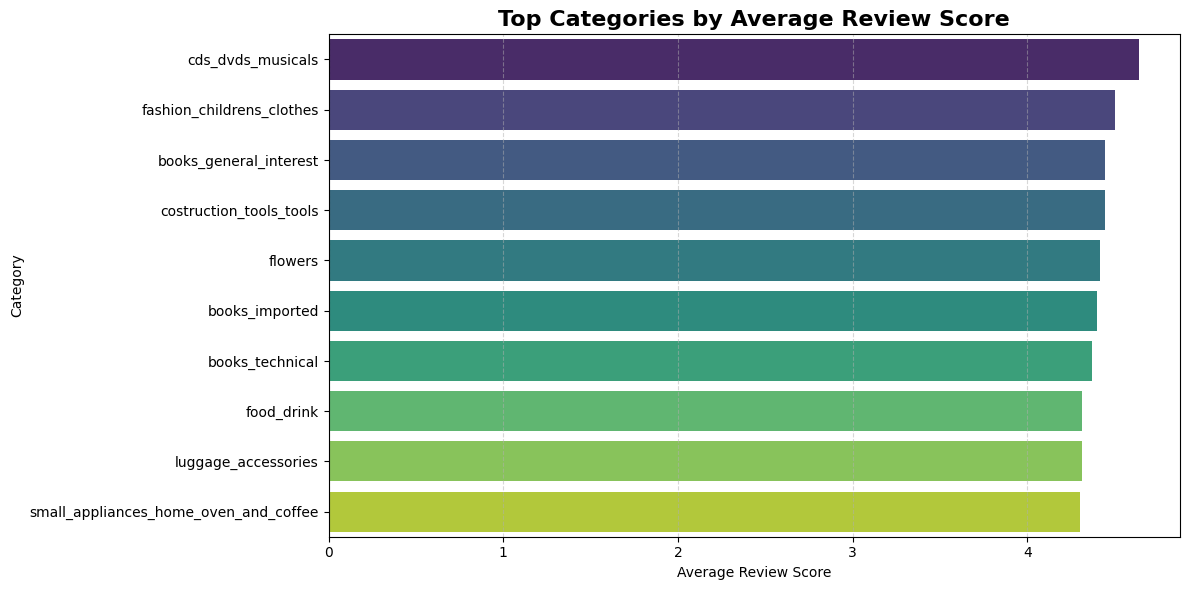

In [63]:
# Visualization

top10 = category_reviews.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="review_score",
    y="product_category_name_english",
    hue="product_category_name_english",
    palette="viridis",
    legend=False
)

plt.title(
    "Top Categories by Average Review Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Review Score")
plt.ylabel("Category")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
Categories with higher average review scores indicate greater customer satisfaction and better product performance.

#### 9. What happens to sales volume across time periods? 
Output: time-based aggregation, line chart, and a seasonal pattern summary. This 
fits the EDA workflow and helps students practice date handling.  

In [64]:
# Monthly Sales Volume

merged_df["order_purchase_timestamp"] = pd.to_datetime(
    merged_df["order_purchase_timestamp"]
)

monthly_sales = (
    merged_df
    .groupby(
        merged_df["order_purchase_timestamp"].dt.to_period("M")
    )["order_id"]
    .nunique()
    .reset_index(name="sales_volume")
)

monthly_sales["order_purchase_timestamp"] = (
    monthly_sales["order_purchase_timestamp"]
    .astype(str)
)

monthly_sales.head()

,order_purchase_timestamp,sales_volume
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


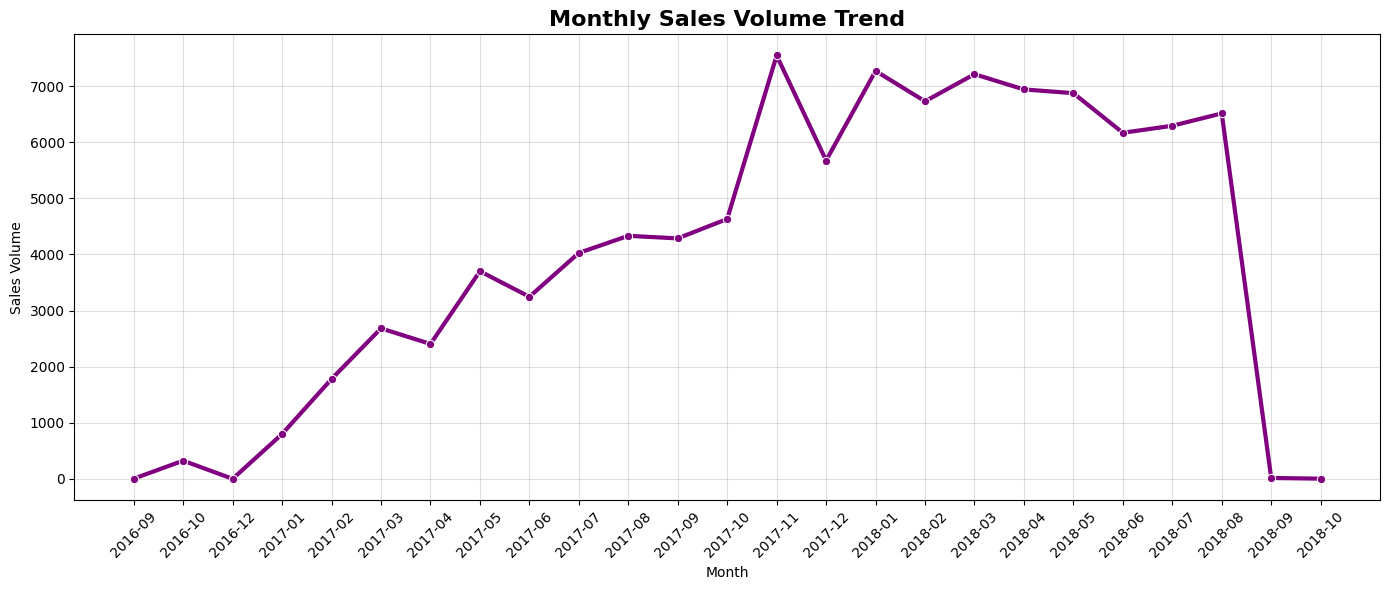

In [65]:
# Visualization

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x="order_purchase_timestamp",
    y="sales_volume",
    marker="o",
    linewidth=3,
    color="purple"
)

plt.title(
    "Monthly Sales Volume Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales Volume")

plt.xticks(rotation=45)

plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

#### Insight:
The monthly sales trend helps identify growth patterns, seasonal demand, and periods of high or low customer activity.

#### 10. Which customers or orders are repeated versus one-time? 
Output: repeat-customer analysis, a simple count table, and a retention-style 
insight. This is a good business-style analysis without needing advanced ML

In [67]:
# Customer Order Count

customer_orders = (
    merged_df
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

customer_orders.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [68]:
# Customer Type

customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_orders.head()

,customer_unique_id,total_orders,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time Customer
2,0000f46a3911fa3c0805444483337064,1,One-Time Customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-Time Customer
4,0004aac84e0df4da2b147fca70cf8255,1,One-Time Customer


In [72]:
# Count Table

retention_summary = (
    customer_orders["customer_type"]
    .value_counts()
    .reset_index()
)

retention_summary.columns = [
    "customer_type",
    "count"
]

retention_summary

,customer_type,count
0,One-Time Customer,93099
1,Repeat Customer,2997


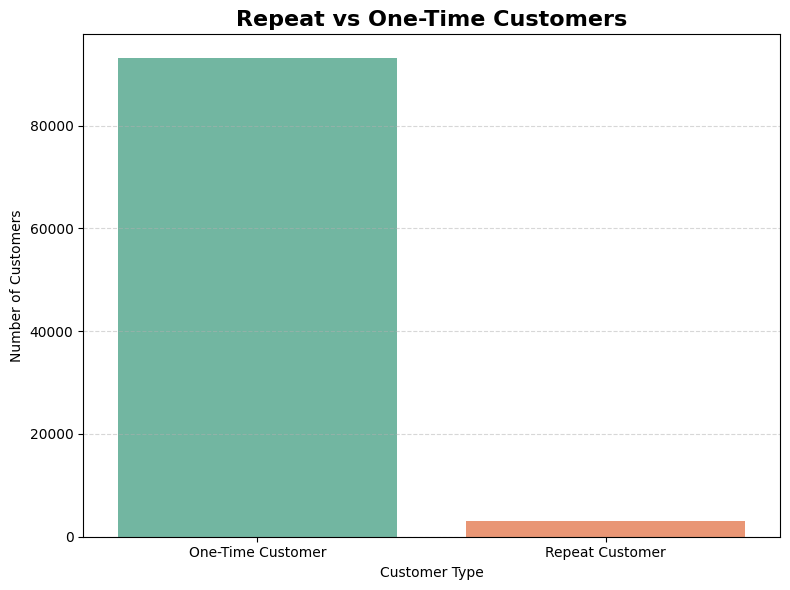

In [73]:
# Visualization

plt.figure(figsize=(8,6))

sns.barplot(
    data=retention_summary,
    x="customer_type",
    y="count",
    hue="customer_type",
    palette="Set2",
    legend=False
)

plt.title(
    "Repeat vs One-Time Customers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
The analysis shows the proportion of repeat and one-time customers, helping evaluate customer retention and loyalty.

# Conclusion

## Findings

* A few product categories contribute the majority of total revenue.
* Sales are concentrated in specific cities and states, indicating strong regional markets.
* Customer purchasing behavior shows clear trends across different time periods.
* A small group of products and sellers generates a significant share of overall revenue.
* Credit card and other popular payment methods dominate customer transactions.
* Customer review scores vary across product categories, highlighting differences in customer satisfaction.
* Sales volume changes over time, suggesting seasonal and demand-based patterns.
* Most customers are one-time buyers, while a smaller segment consists of repeat customers.

## Recommendations

* Increase marketing and inventory investment in top-performing product categories.
* Focus business expansion and promotional campaigns on high-revenue cities and states.
* Strengthen relationships with top-performing sellers and ensure product availability.
* Encourage customers to use preferred payment methods through offers and discounts.
* Investigate low-rated product categories and improve product quality and customer service.
* Launch customer retention programs to convert one-time buyers into repeat customers.
* Use sales trend analysis for better inventory planning and demand forecasting.
* Continuously monitor customer feedback to improve overall customer satisfaction and business performance.
